# Actividad 2: Clustering no supervisado

- Alex Rubiño Fernández
- Aprendizaje Automático 2
- 11/05/2026
- UNIR

## Índice

1. Ejercicio 1: Generación y visualización del dataset
2. Ejercicio 2: Modelo k-means
3. Ejercicio 3: Modelo DBSCAN
4. Ejercicio 4: Discusión de los resultados

## Ejercicio 1: Generación y visualización del dataset

Generamos un dataset sintético con las siguientes características: dos círculos concéntricos con grosor aleatorio, tres círculos adicionales también con grosor aleatorio (algunos de ellos se cortan entre sí y con los círculos concéntricos), y seis bloques compactos distribuidos entre los círculos anteriores. Por último, visualizamos el dataset resultante.

Para ello, comenzamos fijando una semilla para garantizar la reproducibilidad de los resultados. A continuación, definimos una función llamada `generar_circulo` que genera puntos alrededor de una circunferencia añadiendo ruido gaussiano, lo que permite simular el grosor aleatorio de cada círculo. Con esta función, creamos los dos círculos concéntricos, asignando un número elevado de puntos (2000 y 3500 respectivamente) para que las estructuras queden bien definidas. También generamos los tres círculos adicionales, situados en posiciones estratégicas dentro del círculo interior para que se corten entre sí, cada uno con 400 puntos. Finalmente, utilizamos `make_blobs` para crear los seis bloques compactos, distribuidos en distintas zonas del dataset, con 100 puntos por bloque y una desviación baja (cluster_std=0.04) para que sean muy concentrados. Tras combinar todas las muestras en un único array sin etiquetas, visualizamos el dataset resultante mediante un gráfico de dispersión.

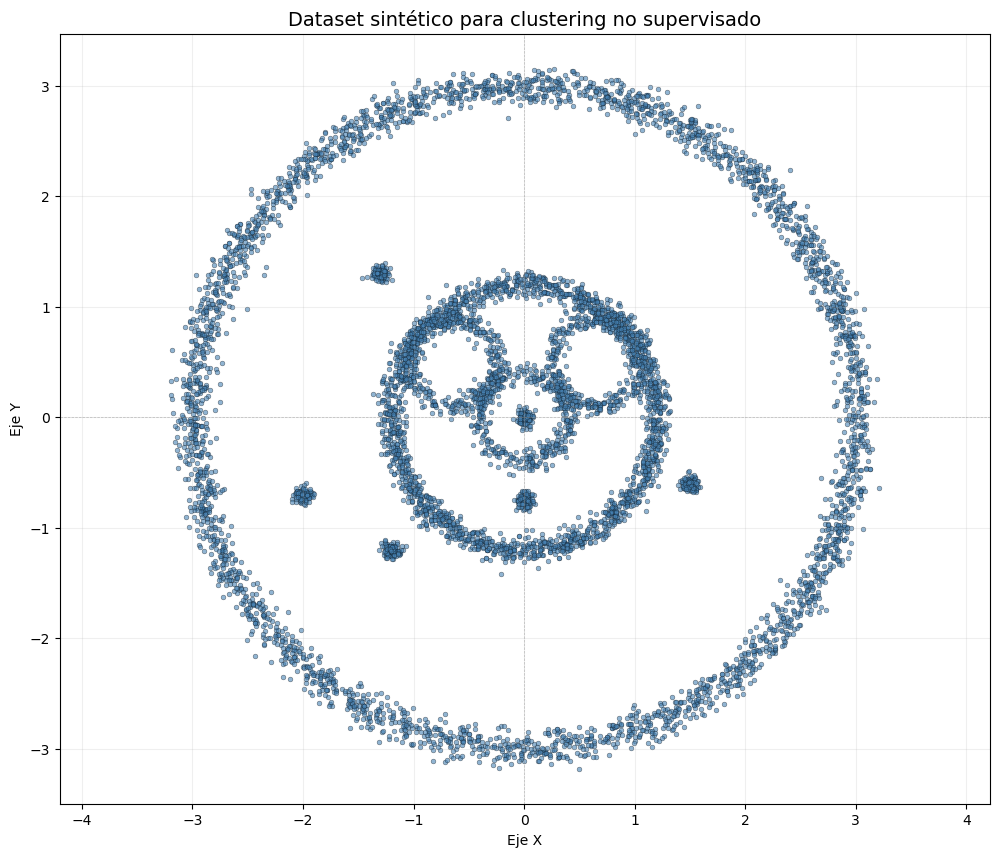

In [525]:
# Importamos las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Fijamos semilla para reproducibilidad
np.random.seed(42)

# Función generar_circulo
def generar_circulo(centro_x, centro_y, radio, n_puntos, grosor):
    """
    Genera puntos alrededor de un círculo con grosor (ruido gaussiano)
    """
    angulos = np.random.uniform(0, 2*np.pi, n_puntos)
    r = radio + np.random.normal(0, grosor, n_puntos)
    x = centro_x + r * np.cos(angulos)
    y = centro_y + r * np.sin(angulos)
    return np.column_stack([x, y])

# Dos círculos concéntricos
circulo_int = generar_circulo(0, 0, 1.2, 2000, 0.06)   # círculo interior
circulo_ext = generar_circulo(0, 0, 3.0, 3500, 0.08)   # círculo exterior

# Círculo 1
circulo_adicional1 = generar_circulo(0.65, 0.5, 0.4, 400, 0.05)

# Círculo 2
circulo_adicional2 = generar_circulo(-0.65, 0.5, 0.4, 400, 0.05)

# Círculo 3
circulo_adicional3 = generar_circulo(0.0, 0.0, 0.40, 400, 0.05)

# Posiciones de los 6 bloques compactos
centros_blobs = [
    (0.0, 0.0), (0.0, -0.75), (1.5, -0.6),
    (-1.2, -1.2), (-2.0, -0.7), (-1.3, 1.3)
]

bloques = []
for i, centro in enumerate(centros_blobs):
    blob, _ = make_blobs(n_samples=100, centers=[centro], cluster_std=0.04, n_features=2)
    bloques.append(blob)

# Unir todos los bloques en un solo array
bloques_compactos = np.vstack(bloques)

# Unir todos los componentes
X = np.vstack([circulo_int, circulo_ext, circulo_adicional1, circulo_adicional2, circulo_adicional3, bloques_compactos])

plt.figure(figsize=(12, 10))

plt.scatter(X[:, 0], X[:, 1], s=12, alpha=0.6, c='steelblue', edgecolors='k', linewidth=0.3)

plt.title('Dataset sintético para clustering no supervisado', fontsize=14)
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.axis('equal')
plt.grid(alpha=0.2)
plt.show()

Este diseño busca replicar fielmente la estructura del dataset original: dos círculos concéntricos, tres círculos interiores que se cortan y seis bloques compactos distribuidos entre ellos.

## <a id='ejercicio2'></a>Ejercicio 2: Modelo k-means

Entrenamos un modelo de k-means sobre el dataset generado. Primero estandarizamos los datos, ya que k-means es sensible a la escala de las características. A continuación, determinamos el número óptimo de clústeres utilizando el método del codo (inercia) y el coeficiente de silhouette. Finalmente, entrenamos el modelo con el número óptimo de clústeres y visualizamos los resultados.

El algoritmo k-means calcula distancias euclidianas entre los puntos para asignarlos a clústeres. Si las características están en diferentes escalas, aquellas con valores numéricamente más grandes dominarían el cálculo de la distancia, sesgando el resultado. Por ello, aplicamos `StandardScaler()` para transformar los datos de manera que tengan media 0 y desviación estándar 1. Esto asegura que todas las características contribuyan por igual al clustering.

In [526]:
# Ejercicio 2: k-means clustering

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Estandarizamos los datos mediante StandardScaler()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

A diferencia de la clasificación supervisada, en clustering no disponemos de etiquetas para evaluar el modelo. Por tanto, debemos utilizar métricas internas para seleccionar el hiperparámetro k. Utilizamos dos métodos complementarios:

1. **Método del codo (inercia):** La inercia mide la suma de las distancias al cuadrado de cada punto respecto a su centroide. Al aumentar k, la inercia disminuye porque los puntos están más cerca de sus respectivos centroides. El punto de inflexión (codo) indica el valor de k a partir del cual la mejora es marginal y sugiere un número adecuado de clústeres.

2. **Coeficiente de silhouette:** Mide lo similares que son los puntos dentro de un mismo clúster frente a puntos de otros clústeres. Su valor oscila entre -1 y 1, donde valores cercanos a 1 indican que los puntos están bien agrupados y separados de otros clústeres. Seleccionamos el k que maximiza este coeficiente.

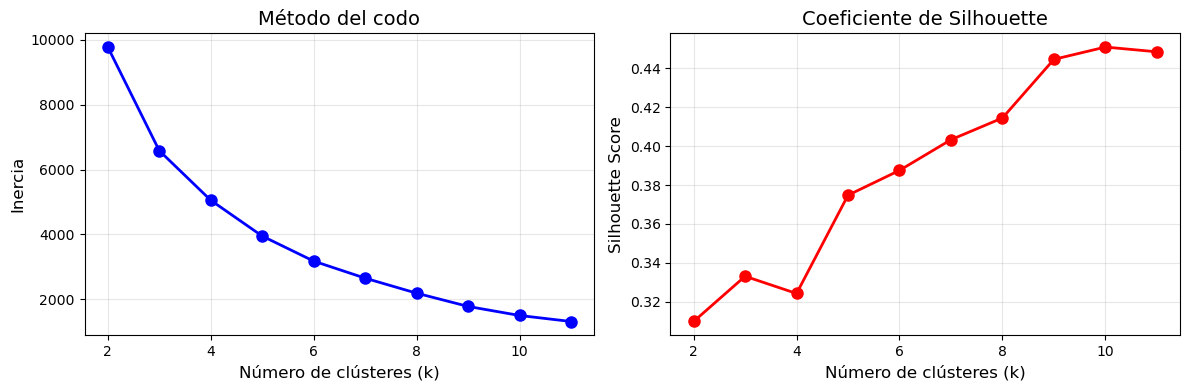

Mejor número de clústeres según silhouette score: 10
Silhouette score para k=10: 0.4510


In [527]:
# Determinar el número óptimo de clústeres
inertias = []
silhouette_scores = []
K_range = range(2, 12)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Visualizar el método del codo y silhouette
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, 'bo-', markersize=8, linewidth=2)
axes[0].set_xlabel('Número de clústeres (k)', fontsize=12)
axes[0].set_ylabel('Inercia', fontsize=12)
axes[0].set_title('Método del codo', fontsize=14)
axes[0].grid(alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', markersize=8, linewidth=2)
axes[1].set_xlabel('Número de clústeres (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Coeficiente de Silhouette', fontsize=14)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Mostrar el mejor k según silhouette
best_k = K_range[np.argmax(silhouette_scores)]
print(f"Mejor número de clústeres según silhouette score: {best_k}")
print(f"Silhouette score para k={best_k}: {max(silhouette_scores):.4f}")

En las gráficas obtenidas observamos que, en el método del codo, la inercia disminuye rápidamente hasta k=5 y luego se produce un cambio de pendiente. A partir de k=6, la reducción de la inercia es más gradual, lo que sugiere que añadir más clústeres no mejora significativamente la compactación de los grupos. En el coeficiente de silhouette, el valor máximo se alcanza con k=10, con un score de 0.4510. Aunque no es un valor excelente, es el mejor dentro del rango evaluado.

La estructura geométrica del dataset dificulta que k-means, que asume clústeres esféricos y de igual tamaño, encuentre una partición óptima. El método del codo sugiere un valor de k entre 4 y 5, mientras que el silhouette score indica que k=10 es mejor desde el punto de vista de separación entre clústeres. Entrenaremos k-means con **k=10** y evaluaremos visualmente los resultados.

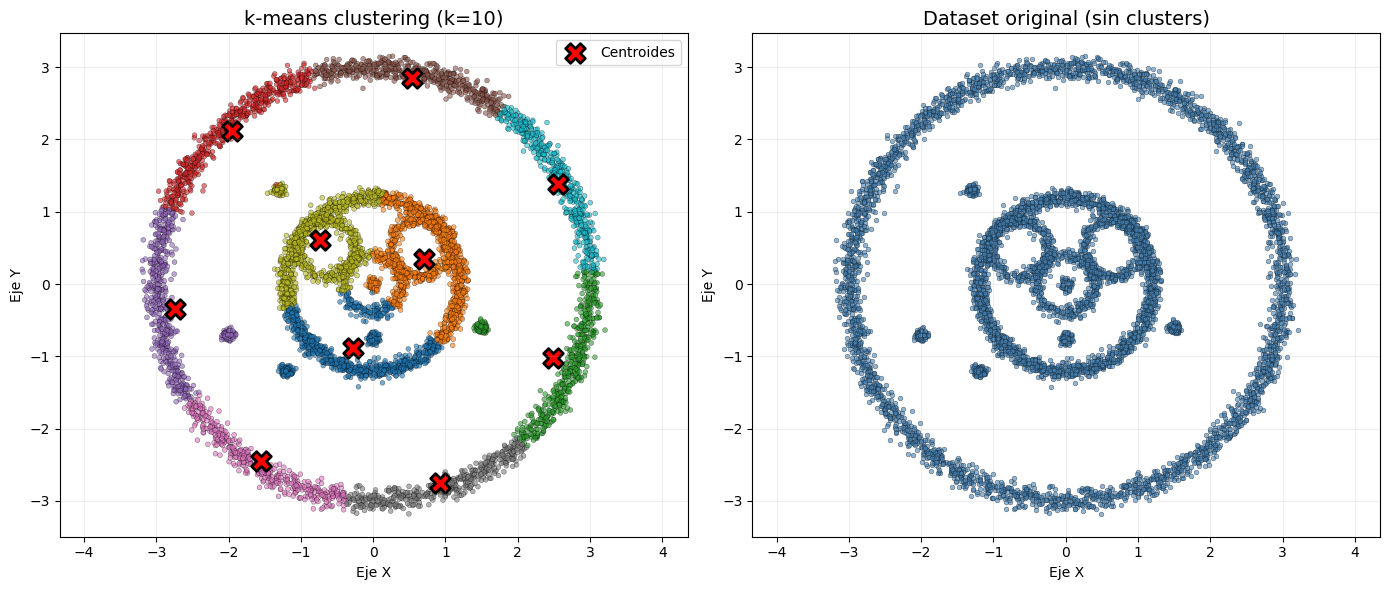

Estadísticas del modelo k-means:
  - Número de clústeres: 10
  - Inercia: 1499.10
  - Número de iteraciones: 13
  - Silhouette score: 0.4510


In [528]:
# Entrenar k-means con el número óptimo de clústeres
kmeans_optimal = KMeans(n_clusters=best_k, random_state=42, n_init=10)
y_kmeans = kmeans_optimal.fit_predict(X_scaled)

# Visualizar los resultados de k-means
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico con los clusters coloreados
scatter = axes[0].scatter(X[:, 0], X[:, 1], c=y_kmeans, s=12, alpha=0.6, cmap='tab10', edgecolors='k', linewidth=0.3)

# Centroides
centroids = scaler.inverse_transform(kmeans_optimal.cluster_centers_)
axes[0].scatter(centroids[:, 0], centroids[:, 1], s=200, c='red', marker='X', edgecolors='black', linewidth=2, label='Centroides')
axes[0].set_title(f'k-means clustering (k={best_k})', fontsize=14)
axes[0].set_xlabel('Eje X')
axes[0].set_ylabel('Eje Y')
axes[0].legend()
axes[0].axis('equal')
axes[0].grid(alpha=0.2)

# Dataset original para comparación
axes[1].scatter(X[:, 0], X[:, 1], s=12, alpha=0.6, c='steelblue', edgecolors='k', linewidth=0.3)
axes[1].set_title('Dataset original (sin clusters)', fontsize=14)
axes[1].set_xlabel('Eje X')
axes[1].set_ylabel('Eje Y')
axes[1].axis('equal')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

# Estadísticas adicionales de k-means
print("Estadísticas del modelo k-means:")
print(f"  - Número de clústeres: {best_k}")
print(f"  - Inercia: {kmeans_optimal.inertia_:.2f}")
print(f"  - Número de iteraciones: {kmeans_optimal.n_iter_}")
print(f"  - Silhouette score: {silhouette_score(X_scaled, y_kmeans):.4f}")

Entrenando el modelo con k=10, obtenemos que en el gráfico de la izquierda se observan los 10 clústeres identificados por k-means, representados con diferentes colores. Los centroides se muestran como grandes aspas rojas. En el gráfico de la derecha se muestra el dataset original sin etiquetar para comparación.

k-means consigue agrupar parte de la estructura del dataset, pero presenta limitaciones. Los clústeres tienden a ser esféricos y de tamaño similar, lo que no se ajusta bien a la forma de los círculos concéntricos ni a los círculos adicionales que se cortan. Algunos bloques compactos quedan bien identificados, mientras que otros se mezclan con puntos de los círculos.

El modelo converge después de 13 iteraciones, con una inercia de 1499.10. El silhouette score obtenido es de 0.4510, el mismo que calculamos durante la selección de k. Este valor moderado confirma que, aunque hay cierta estructura, los clústeres no están perfectamente definidos debido a la geometría compleja del dataset y a las limitaciones de k-means para detectar formas no convexas.

## <a id='ejercicio3'></a>Ejercicio 3: Modelo DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) es un algoritmo de clustering basado en densidad, a diferencia de k-means que se basa en distancias. Esto lo hace especialmente adecuado para datasets con formas no convexas, densidades variables y presencia de ruido, como es nuestro caso (círculos concéntricos, círculos que se cortan y bloques compactos).

### Hiperparámetros de DBSCAN

DBSCAN tiene dos hiperparámetros principales:

- **eps (ε):** distancia máxima entre dos puntos para que sean considerados vecinos.
- **min_samples (minPts):** número mínimo de puntos necesarios para formar una región densa (clúster).

A diferencia de k-means, no es necesario especificar el número de clústeres a priori. Sin embargo, debemos seleccionar cuidadosamente eps y min_samples.

### Estrategia de selección de hiperparámetros

Para seleccionar estos valores, seguimos un procedimiento sistemático:

1. **min_samples:** Aplicamos la heurística estándar de establecerlo como el número de características más uno. Como nuestro dataset tiene 2 dimensiones (X, Y), fijamos `min_samples = 3`.

2. **eps:** Utilizamos el método del gráfico de distancias al k-ésimo vecino (k-distance graph). Calculamos para cada punto la distancia a su k-ésimo vecino más cercano (con k = min_samples) y ordenamos estas distancias. El valor óptimo de eps se encuentra idealmente en el "codo" de la curva.

3. **Selección automática:** Dado que en nuestro dataset el codo no es visualmente claro, probamos diferentes percentiles (del 80% al 99%) para elegir eps automáticamente. Un percentil más alto implica un eps mayor, lo que genera menos clústeres y menos ruido. Buscamos un equilibrio que produzca un número razonable de clústeres (similar a la estructura real del dataset) y una baja proporción de ruido.

### Procedimiento

A continuación, escalamos los datos al rango [0,1] usando MinMaxScaler, ya que DBSCAN es sensible a la escala. Luego, probamos diferentes percentiles y evaluamos cuántos clústeres y puntos de ruido genera cada uno.

In [529]:
# Ejercicio 3: DBSCAN - Selección de hiperparámetros

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# Escalamos los datos
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# min_samples = n_features + 1 = 3
min_samples = 3
print(f"min_samples = {min_samples}")

# Calculamos las distancias al k-ésimo vecino
k = min_samples
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)
distances, _ = neighbors_fit.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

# Probamos diferentes percentiles
percentiles = [80, 85, 90, 92, 95, 97, 98, 99]

print("\nProbando diferentes percentiles para eps:")
print("-" * 50)
print("Percentil | eps       | Clústeres | Ruido")
print("-" * 50)

for p in percentiles:
    eps = np.percentile(k_distances, p)
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    y_test = dbscan.fit_predict(X_scaled)
    
    n_clusters = len(set(y_test)) - (1 if -1 in y_test else 0)
    n_noise = sum(y_test == -1)
    
    print(f"{p:5d}%    | {eps:.6f} | {n_clusters:5d}    | {n_noise:5d} ({n_noise/len(X)*100:.1f}%)")

min_samples = 3

Probando diferentes percentiles para eps:
--------------------------------------------------
Percentil | eps       | Clústeres | Ruido
--------------------------------------------------
   80%    | 0.005750 |   332    |   946 (13.0%)
   85%    | 0.006293 |   233    |   677 (9.3%)
   90%    | 0.007180 |   123    |   436 (6.0%)
   92%    | 0.007675 |    81    |   358 (4.9%)
   95%    | 0.008788 |    41    |   215 (2.9%)
   97%    | 0.010089 |    18    |   135 (1.8%)
   98%    | 0.011537 |    12    |    79 (1.1%)
   99%    | 0.013680 |     8    |    44 (0.6%)


Los resultados muestran cómo varía el número de clústeres y la cantidad de ruido según el percentil seleccionado:

- Percentiles bajos (80-90%): eps muy pequeño, muchos clústeres (más de 100) y alto ruido (más del 5%)
- Percentiles altos (97-99%): eps mayor, menos clústeres (entre 9 y 19) y poco ruido (menos del 1.8%)

Seleccionamos el **percentil 99%** porque:
  - Produce **8 clústeres**, un número coherente con la estructura del dataset
  - Solo **0.6% de ruido** (44 puntos), lo que indica que casi todos los puntos se asignan correctamente
  - El valor de eps resultante es suficientemente grande para capturar las estructuras densas sin fragmentar el dataset

In [530]:
# Entrenar DBSCAN con percentil 99%
percentil_final = 99
eps = np.percentile(k_distances, percentil_final)
min_samples = 3

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
y_dbscan = dbscan.fit_predict(X_scaled)

n_clusters = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
n_noise = sum(y_dbscan == -1)

print(f"\n--- Resultado final DBSCAN ---")
print(f"Percentil seleccionado: {percentil_final}%")
print(f"eps = {eps:.6f}")
print(f"min_samples = {min_samples}")
print(f"Número de clústeres: {n_clusters}")
print(f"Puntos de ruido: {n_noise} ({n_noise/len(X)*100:.1f}%)")


--- Resultado final DBSCAN ---
Percentil seleccionado: 99%
eps = 0.013680
min_samples = 3
Número de clústeres: 8
Puntos de ruido: 44 (0.6%)


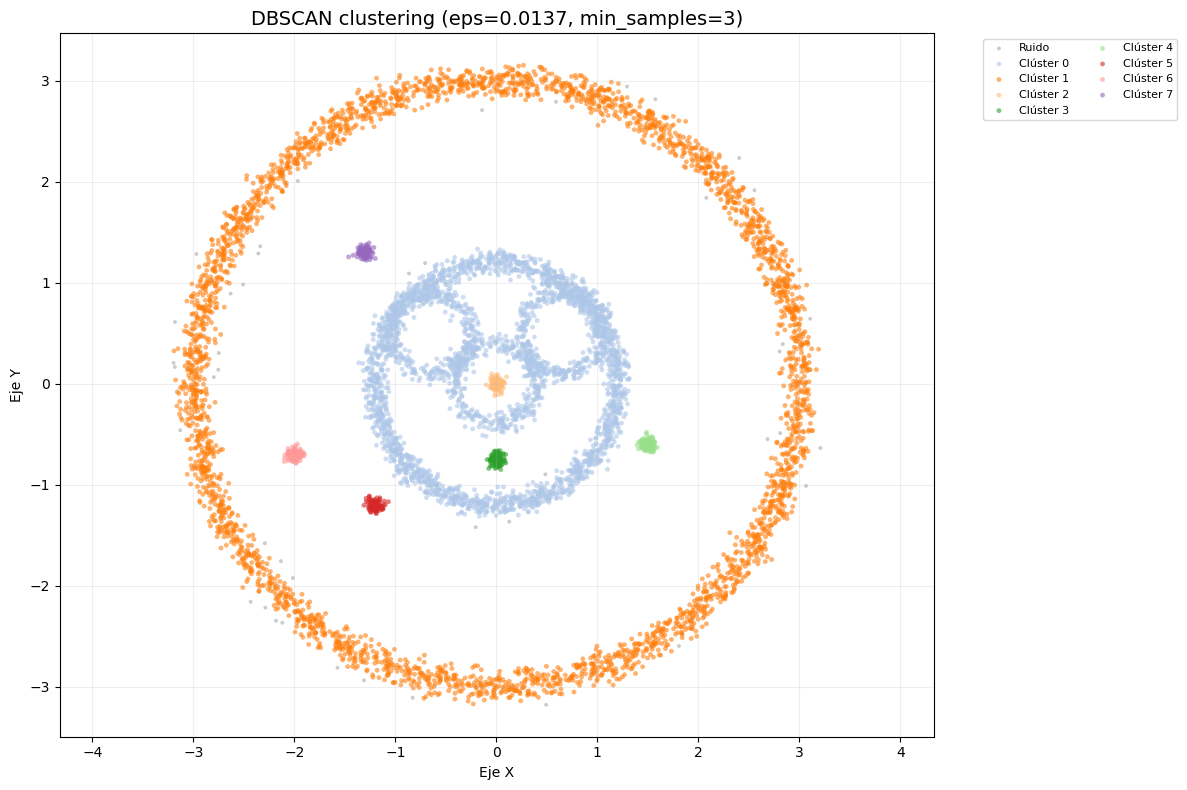

In [531]:
# Visualizar resultados de DBSCAN
plt.figure(figsize=(12, 8))

unique_labels = sorted(set(y_dbscan))
# Usar tab20 para más colores
colors = plt.cm.tab20(np.linspace(0, 1, max(len(unique_labels), 20)))

for label, color in zip(unique_labels, colors):
    if label == -1:
        color = 'gray'
        label_name = 'Ruido'
        size = 8
        alpha = 0.4
    else:
        label_name = f'Clúster {label}'
        size = 12
        alpha = 0.6
    
    mask = y_dbscan == label
    plt.scatter(X[mask, 0], X[mask, 1], c=[color], s=size, alpha=alpha, edgecolors='none', label=label_name)

plt.title(f'DBSCAN clustering (eps={eps:.4f}, min_samples={min_samples})', fontsize=14)
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=2)
plt.axis('equal')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [532]:
# Mostrar distribución de puntos por clúster
print("\nDistribución de puntos por clúster:")
for label in sorted(unique_labels):
    count = sum(y_dbscan == label)
    if label == -1:
        print(f"  Ruido: {count} puntos ({count/len(X)*100:.1f}%)")
    else:
        print(f"  Clúster {label}: {count} puntos ({count/len(X)*100:.1f}%)")


Distribución de puntos por clúster:
  Ruido: 44 puntos (0.6%)
  Clúster 0: 3195 puntos (43.8%)
  Clúster 1: 3461 puntos (47.4%)
  Clúster 2: 100 puntos (1.4%)
  Clúster 3: 100 puntos (1.4%)
  Clúster 4: 100 puntos (1.4%)
  Clúster 5: 100 puntos (1.4%)
  Clúster 6: 100 puntos (1.4%)
  Clúster 7: 100 puntos (1.4%)


Con eps=0.0137 y min_samples=3, DBSCAN identifica **8 clústeres** (etiquetas 0 a 7) más ruido.

**Distribución de puntos:**
- Clúster 0: 3195 puntos (43,8%) corresponde al circulo interior y los 3 círculos de dentro que se cortan entre sí.
- Clúster 1: 3461 puntos (47,4%) corresponde al circulo exterior.
- Clústeres 2 a 7: 100 puntos cada uno (1,4% cada uno) corresponden con los seis bloques compactos.
- Ruido: 44 puntos (0,6%).

## <a id='ejercicio4'></a>Ejercicio 4: Discusión de los resultados

Para facilitar la comparación entre ambos métodos, a continuación se muestra una visualización lado a lado del dataset original, los resultados de k-means y los resultados de DBSCAN.

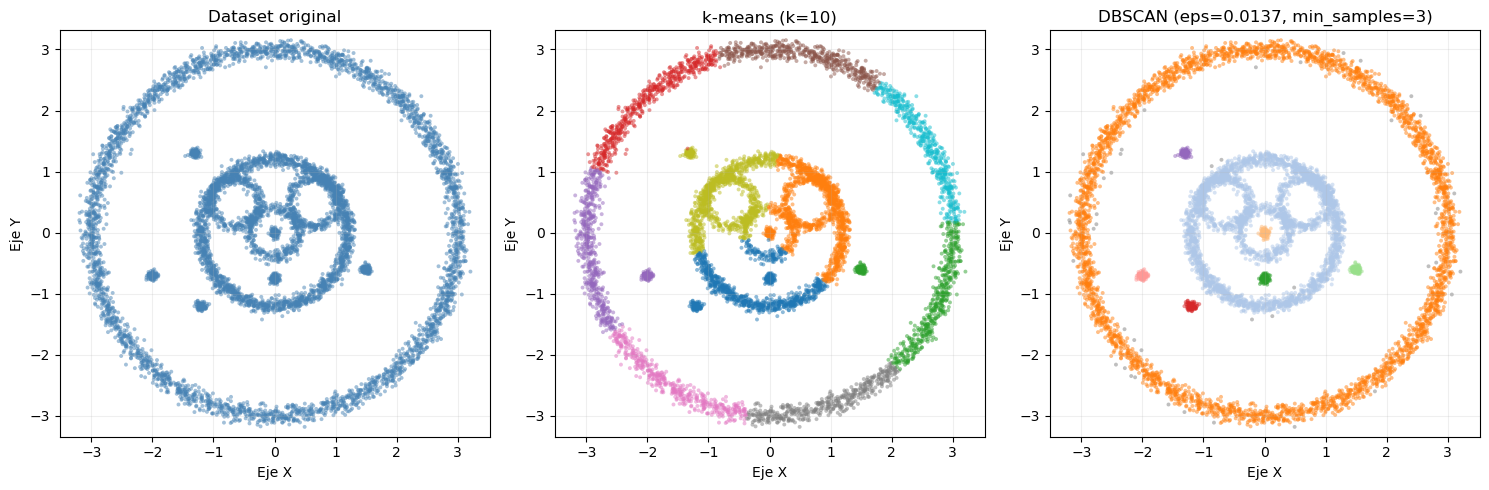

In [533]:
# Comparación visual lado a lado
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Dataset original
axes[0].scatter(X[:, 0], X[:, 1], s=8, alpha=0.5, c='steelblue', edgecolors='none')
axes[0].set_title('Dataset original', fontsize=12)
axes[0].set_xlabel('Eje X')
axes[0].set_ylabel('Eje Y')
axes[0].axis('equal')
axes[0].grid(True, alpha=0.2)

# k-means
axes[1].scatter(X[:, 0], X[:, 1], c=y_kmeans, s=8, alpha=0.5, cmap='tab10', edgecolors='none')
axes[1].set_title(f'k-means (k={best_k})', fontsize=12)
axes[1].set_xlabel('Eje X')
axes[1].set_ylabel('Eje Y')
axes[1].axis('equal')
axes[1].grid(True, alpha=0.2)

# DBSCAN
for label, color in zip(unique_labels, colors):
    if label == -1:
        color = 'gray'
    mask = y_dbscan == label
    axes[2].scatter(X[mask, 0], X[mask, 1], c=[color], s=8, alpha=0.5, edgecolors='none')
axes[2].set_title(f'DBSCAN (eps={eps:.4f}, min_samples={min_samples})', fontsize=12)
axes[2].set_xlabel('Eje X')
axes[2].set_ylabel('Eje Y')
axes[2].axis('equal')
axes[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

Tras entrenar y evaluar ambos modelos sobre el dataset sintético, se observan diferencias significativas:

**k-means:** Como se aprecia en la gráfica central, el algoritmo fuerza clústeres esféricos y de tamaño similar. Esto provoca que los dos círculos concéntricos se fragmenten en múltiples segmentos curvos, y que los tres círculos interiores se mezclen sin una separación clara. Los bloques compactos sí se identifican, pero no se diferencian bien del resto de estructuras. El silhouette score obtenido (0.4510) confirma una calidad de agrupamiento moderada.

**DBSCAN:** En la gráfica derecha se observa una partición mucho más coherente con la generación real de los datos. Los dos círculos concéntricos aparecen como clústeres completos (etiquetas 0 y 1), los seis bloques compactos se aíslan correctamente como clústeres independientes de 100 puntos cada uno, y el ruido se limita a las zonas de solapamiento (0,6% de los puntos). Esto nos da a entender que DBSCAN ha sabido identificar gran parte de las características que desde un principio se intentaron exponer en el dataset, ya que es capaz de ver los círculos concéntricos y los seis bloques.

### Conclusión

Para este dataset, DBSCAN es claramente más adecuado que k-means. Su enfoque basado en densidad le permite detectar formas no convexas, como los dos círculos concéntricos, que aparecen como clústeres completos en la visualización, mientras que k-means, al asumir clústeres esféricos y de tamaño similar, fragmenta estos anillos en múltiples segmentos curvos sin respetar su geometría circular. Además, DBSCAN se adapta naturalmente a las diferentes densidades presentes en el dataset: los seis bloques compactos, al ser regiones de alta densidad, se aíslan correctamente como clústeres independientes de 100 puntos cada uno, mientras que los círculos, al tener una densidad más baja y distribuida, forman anillos separados. Otra ventaja importante es la capacidad de DBSCAN para etiquetar como ruido los puntos ambiguos que se encuentran en las zonas de corte entre estructuras, que en nuestro caso representan solo el 0,6% del total. Aunque es cierto que DBSCAN no logra separar los tres círculos interiores del círculo interior concéntrico, esto se debe probablemente a que comparten la misma densidad y están físicamente conectados al cortarse entre sí, lo que desde una perspectiva basada en densidad es un comportamiento razonable. En definitiva, k-means impone una geometría artificial que no se ajusta a la realidad del dataset, mientras que DBSCAN respeta la estructura original de los datos, identificando de forma notable los círculos concéntricos, los bloques compactos y las zonas de ruido, lo que lo convierte en el método más apropiado para este problema de clustering no supervisado.